In [37]:
# Run the following to empty the VRAM:
import gc
import torch
# del model, tokenizer, pipe

# Flush memory
gc.collect()
torch.cuda.empty_cache()

In [38]:
from importlib.metadata import version

pkgs = ["tokenizers", 
        "numpy", 
        "tiktoken", 
        "torch",
        "transformers",
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

tokenizers version: 0.21.1
numpy version: 1.26.4
tiktoken version: 0.9.0
torch version: 2.3.1
transformers version: 4.51.3


In [3]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.version.cuda)         # Check CUDA version
print(torch.__version__)          # PyTorch version

torch.device('cuda' if torch.cuda.is_available() else 'cpu')

True
12.1
2.3.1+cu121


device(type='cuda')

In [39]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model_name = "Qwen/Qwen3-1.7B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

https://dailyamardesh.com/world/amd3kltlmc85w

### Load data and format prompt

In [ ]:
# !pip install datasets

In [7]:
from datasets import load_dataset

# Formatting dataset for finetune Qwen-Code-3B
def format_qwen_data(data):
    return {
        "text": (
            f"<|im_start|>user\n{data['content']}<|im_end|>\n"
            f"<|im_start|>assistant\n{data['content_summary']}<|im_end|>"
        )
    }
    
# Load and format the data using the template TinyLLama is using
train_dataset = (
    load_dataset("kawsarahmd/papers_summary_datasets_v4", split="train")
      .shuffle(seed=42)
)

test_dataset = (
    load_dataset("kawsarahmd/papers_summary_datasets_v4", split="test")
      .shuffle(seed=42)
)
val_dataset = (
    load_dataset("kawsarahmd/papers_summary_datasets_v4", split="validation")
      .shuffle(seed=42)
)

# Apply formatting to each split
train_dataset = train_dataset.map(format_qwen_data)
test_dataset = test_dataset.map(format_qwen_data)
val_dataset = val_dataset.map(format_qwen_data)

In [8]:
# Example of formatted prompt
print(train_dataset['text'][0])

<|im_start|>user
গ্রাহকের ঠিকানায় পণ্য পৌঁছে দেওয়ার প্রচলিত কাঠামোর পাশাপাশি কর্মীদের সাথে মুনাফা ভাগের প্রতিশ্রুতি নিয়ে সোশ্যাল এন্টারপ্রাইজ হিসেবে যাত্রা শুরু করল অনলাইন শপ‘গোগ্রাবি ডটকম’।
এক সংবাদ বিজ্ঞপ্তিতে জানানো হয়, স্থানীয় প্রতিষ্ঠান নেক্সিও রিটেইল কনসেপ্টস লিমিটেডের ইকমার্স  উদ্যোগ হিসেবে অক্টোবর মাসের প্রথম দিন থেকে ওয়েব এবং মোবাইল অ্যাপলিকেশন— দুই মাধ্যমেই রাজধানী ঢাকার গ্রাহকদের জন্য ‘দ্রুত এবং সাশ্রয়ী’ বাজার সদাই পৌঁছে দেবে গোগ্রাবি।
গোগ্রাবির প্রতিষ্ঠাতা ও প্রধান নির্বাহী জিয়াউর রহমান বলেন, ‘প্রযুক্তির মাধ্যমে নিত্য বাজার সদাই ব্যবসার সাথে সাথে দারিদ্র্য দূর করা ও নীতি-নৈতিকতার মাধ্যমে সবুজতর ভবিষ্যতের দিকে এগিয়ে যাচ্ছি আমরা।’ মানুষ এবং সমাজের জন্য ভালো কিছু করার মূল মন্ত্র নিয়ে গোগ্রাবি যাত্রা শুরু করেছে বলে জানান তিনি।
বিলিকর্মী ধারণার নতুন সংস্করণ ‘শপারস’ এর মাধ্যমে নিবন্ধিত কর্মীদের মাধ্যমে গ্রাহকের ঠিকানায় বাজার পৌঁছাবে গোগ্রাবি শেয়ার্ডইকোনমি অনুসারে শপার্সদের সাথে মুনাফা ভাগ করে নেবে প্রতিষ্ঠানটি।
ঢাকা শহরের ৩০০ বাজারের ১০,০০০ দোকানদার গোগ্রাবি প্লাটফর্মে যুক্ত হয়েছ

### Loading Quantize configure of the model

In [ ]:
# !pip install -U bitsandbytes

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# Base model selection
base_model = "Qwen/Qwen3-1.7B"

# 4-bit quantization configuration - Q in QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,  # Use 4-bit precision model loading
    bnb_4bit_quant_type="nf4",  # Quantization type
    bnb_4bit_compute_dtype="float16",  # Compute dtype
    bnb_4bit_use_double_quant=True,  # Apply nested quantization
)

# Load the model to train on the GPU
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    device_map="auto",
    quantization_config=bnb_config,
)
model.config.use_cache = False
model.config.pretraining_tp = 1

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model, trust_remote_code=True)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
tokens = tokenizer.encode(train_dataset['text'][51])
len(tokens)

2738

### LoRA adapter using PEFT

In [11]:
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model

# Prepare LoRA Configuration
peft_config = LoraConfig(
    lora_alpha=32,  # LoRA Scaling
    lora_dropout=0.1,  # Dropout for LoRA Layers
    r=64,  # Rank
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=  # Layers to target
     ["k_proj", "gate_proj", "v_proj", "up_proj", "q_proj", "o_proj", "down_proj"]
)

# Prepare model for training
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, peft_config)

### Training argument 

In [12]:
from transformers import TrainingArguments
from trl import SFTConfig, SFTTrainer

output_dir = "./qwen3-1.7B-bang-summary"

training_arguments = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size= 2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    num_train_epochs=1,
    logging_steps=7,
    fp16=True,
    gradient_checkpointing=True,

    # Added for validation and checkpointing
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{output_dir}/logs"
)

### Supervised Fine Tune using SFT Trainer

In [13]:
torch.cuda.empty_cache()
# !nvidia-smi

In [14]:
from trl import SFTTrainer

# Set supervised fine-tuning parameters with validation support
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,         # 90% training split
    eval_dataset=val_dataset,     # 5% validation split
    dataset_text_field="text",
    tokenizer=tokenizer,
    args=training_arguments,
    max_seq_length=1024,
    peft_config=peft_config,                      # Leave this only if doing QLoRA/PEFT
)

# Train model
trainer.train()

Map:   0%|          | 0/15752 [00:00<?, ? examples/s]

Map:   0%|          | 0/876 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
100,0.831800,0.823813
200,0.781700,0.783832
300,0.766800,0.758600
400,0.750500,0.737587
500,0.746700,0.721807
600,0.710600,0.708333
700,0.683300,0.697510
800,0.683400,0.687131
900,0.703100,0.677820
1000,0.670800,0.670978


TrainOutput(global_step=1969, training_loss=0.7032175279014785, metrics={'train_runtime': 5340.617, 'train_samples_per_second': 2.949, 'train_steps_per_second': 0.369, 'total_flos': 1.428092201006162e+17, 'train_loss': 0.7032175279014785, 'epoch': 1.0})

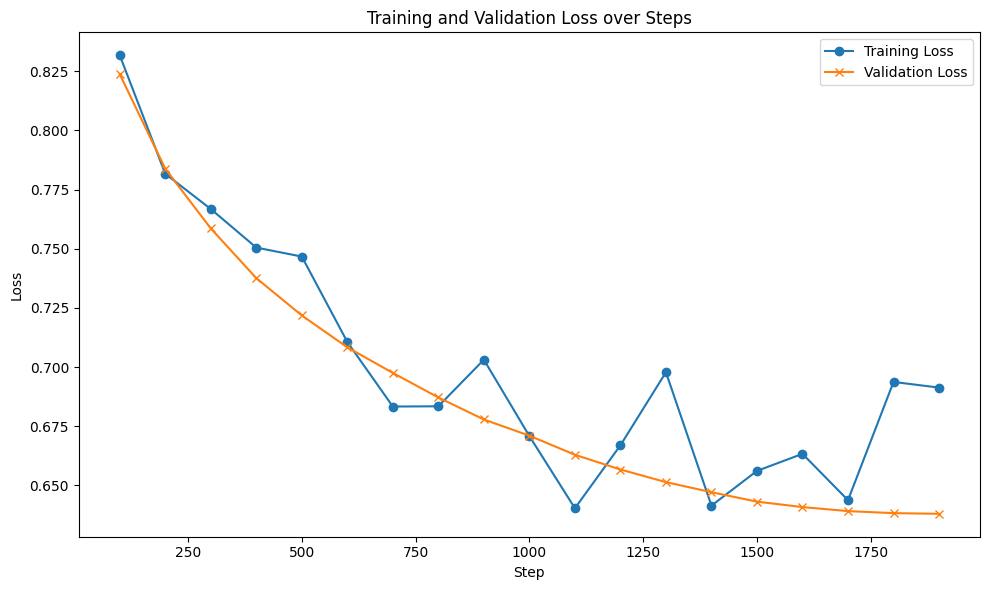

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Step-wise training and validation loss data
data = {
    "Step": [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000,
             1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900],
    "Training Loss": [0.831800, 0.781700, 0.766800, 0.750500, 0.746700,
                      0.710600, 0.683300, 0.683400, 0.703100, 0.670800,
                      0.640300, 0.666900, 0.697800, 0.641400, 0.656100,
                      0.663300, 0.643700, 0.693700, 0.691300],
    "Validation Loss": [0.823813, 0.783832, 0.758600, 0.737587, 0.721807,
                        0.708333, 0.697510, 0.687131, 0.677820, 0.670978,
                        0.662910, 0.656680, 0.651343, 0.647084, 0.643094,
                        0.640795, 0.639093, 0.638234, 0.637956]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df["Step"], df["Training Loss"], marker='o', label='Training Loss')
plt.plot(df["Step"], df["Validation Loss"], marker='x', label='Validation Loss')
plt.title("Training and Validation Loss over Steps")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(False)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Save QLoRA weights (not full model if using PEFT)
trainer.model.save_pretrained("qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary")
tokenizer.save_pretrained("qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary")

('qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/tokenizer_config.json',
 'qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/special_tokens_map.json',
 'qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/vocab.json',
 'qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/merges.txt',
 'qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/added_tokens.json',
 'qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary/tokenizer.json')

### Cleaning VRAM and space

In [44]:
# Run the following to empty the VRAM: Not in Book
import gc
import torch
# del model, trainer

# Flush memory
torch.cuda.empty_cache()
gc.collect()

1391

### Merged Adapter weight to base model

In [45]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# Load the base model (ensure this is the same base model used for fine-tuning)
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B", 
     device_map="auto",
     torch_dtype="auto",
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained("qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary")

# Load the fine-tuned model with the adapter
model = PeftModel.from_pretrained(base_model, "qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

### Inference

In [48]:
# prepare the model input
prompt = """
গুজরাটের পুলিশ বলছে শনিবার ভোর রাত থেকে সোমবার রাত পর্যন্ত সাড়ে ছয় হাজার মানুষকে তারা আটক করেছে, যারা বাংলাদেশি নাগরিক বলে পুলিশের সন্দেহ। তবে নিশ্চিতভাবে ৪৫০ জন বাংলাদেশিকে তারা চিহ্নিত করতে পেরেছেন বলে জানিয়েছেন রাজ্য পুলিশের মহা-নির্দেশক বিকাশ সহায়।


সংবাদসংস্থা পিটিআই সোমবার রাতে মি. সহায়কে উদ্ধৃত করে জানিয়েছে, "নথির ভিত্তিতে এখনও পর্যন্ত এটা নিশ্চিত করা গেছে যে ৪৫০ জন বাংলাদেশি নাগরিক বেআইনিভাবে এখানে থাকছিলেন। আটক হওয়া বাকিদের জিজ্ঞাসাবাদ চলছে। আমাদের মনে হচ্ছে যে একটা বড় সংখ্যায় বেআইনি বাংলাদেশিদের পরিচয় আমরা নিশ্চিত করতে পারব।"

শনিবার ভোর রাত থেকে প্রথমে আহমেদাবাদ ও সুরাতে এবং তারপরের দুদিনে পুরো গুজরাটেই 'বেআইনি বাংলাদেশি' আটক করার জন্য অপারেশন চালাচ্ছে গুজরাট পুলিশ।

"রাত তিনটে নাগাদ পুলিশ আসে আমাদের বাসায়। আমার স্বামী, বাচ্চাদের– সবার আধার কার্ড দেখতে চায়। তারপরে তারা আমার স্বামী আর দুই ভাগ্নেকে নিয়ে যায়। ওরা বলেছিল যে কিছুক্ষণের মধ্যেই ফিরে আসবে আমার স্বামী। কিন্তু প্রায় তিন দিন হতে চলল, তিনি ফেরেননি," বিবিসি বাংলাকে বলছিলেন সুরাত থেকে বাংলাদেশি সন্দেহে আটক হওয়া সুলতান মল্লিকের স্ত্রী সাহিনা বিবি।

যেদিন প্রথম অপারেশন শুরু হয়, সেদিনই আটক হন মি. মল্লিক ও তার দুই কিশোর ভাগ্নে।

বাংলাদেশি সন্দেহেই এদের আটক করা হয়, তবে বিবিসি বাংলার হাতে মি. মল্লিকের পাসপোর্ট ও ১৯৯৩ সালের একটি জমির দলিল হাতে এসেছে, যেখানে দেখা যাচ্ছে তিনি পশ্চিমবঙ্গের বীরভূম জেলার লাভপুর অঞ্চলের বাসিন্দা।

পশ্চিমবঙ্গের সুলতান মল্লিক কেন আটক?

সুলতান মল্লিক বছর ছয়েক ধরে সুরাতে এমব্রয়ডারির কাজ করেন।

তার স্ত্রীর কথায়, "প্রথমে তো জানতেই পারিনি যে কোন থানায় নিয়ে গেছে, কোথায় রেখেছে। শনিবার বেলার দিকে আমার স্বামী পুলিশের একটা নম্বর থেকেই ফোন করে জানায় যে তাদের কোনও একটা গুদাম ঘরে রেখেছে। সব নথি হোয়াটসঅ্যাপে পাঠাতে বলেন আমার স্বামী। পাসপোর্ট, জমির দলিল – যা যা প্রমাণ ছিল, সব পাঠিয়েছি। কিন্তু তারপর থেকে সোমবার রাত পর্যন্ত আর কোনও যোগাযোগ নেই। এদিকে আমার শাশুড়ি অসুস্থ হয়ে পড়েছেন তার ছেলের এই দশা দেখে, আমার বড় মেয়েটা অজ্ঞান হয়ে গিয়েছিল। মাত্র একবছর হলো আমি গুজরাটে এসেছি– এখন কোথায় স্বামীর খোঁজ করতে যাব বুঝতে পারছি না।"

পরিযায়ী শ্রমিকদের নিয়ে কাজ করে, এমন একটি সংগঠন 'পরিযায়ী শ্রমিক ঐক্য মঞ্চ' গুজরাটের ধরপাকড় শুরু হওয়ার পরে একটি হেল্পলাইন খুলেছে। প্রিয়জনের খোঁজ পাওয়ার জন্য ওই হেল্প লাইনে গত দুদিনে প্রিয়জনের খোঁজ না পাওয়া একশোরও বেশি অভিযোগ জমা পড়েছে বলে জানাচ্ছিলেন সংগঠনটির রাজ্য সম্পাদক আসিফ ফারুক।

"গুজরাটে সংখ্যাটা বড়, তাই বিষয়টা ব্যাপক আলোচনায় উঠে এসেছে। কিন্তু উত্তরপ্রদেশ, ওড়িশা আর মহারাষ্ট্রেও পশ্চিমবঙ্গের বাংলাভাষী মুসলমানদের 'বাংলাদেশি' তকমা দিয়ে হেনস্থা করার ঘটনা সম্প্রতি খুব বেড়ে গেছে। এরকম পরিস্থিতি হতে যাচ্ছে এই আশঙ্কা করেই আমরা গত সপ্তাহে স্বরাষ্ট্রমন্ত্রী অমিত শাহকে একটা চিঠিও দিয়েছিলাম। কিন্তু তাতে কাজ যে কিছু হয়নি, দেখাই যাচ্ছে," বলছিলেন মি. ফারুক।

তার কথায়, "আরও একটা গুরুতর বিষয় জানতে পারলাম মি. মল্লিকের ব্যাপারে। আটক হওয়ার ২৪ ঘণ্টার মধ্যেই আদালতে পেশ করার কথা। কিন্তু তিনদিন হয়ে গেল তাদের আটক করা হয়েছে, আদালতে কেন পেশ করা হল না এখনও!"

বরযাত্রীদের ধরে নিয়ে গেছে পুলিশ

'বাংলাদেশি'দের খোঁজে পুলিশ অপারেশন শুরু হওয়ার কয়েক ঘণ্টা পরে আহমেদাবাদ পুলিশের 'ক্রাইম ব্রাঞ্চ' দফতরের সামনে বিবিসি গুজরাটি সংবাদদাতা তেজশ ভৈদের সঙ্গে দেখা হয়েছিল মিজ. ফারজানার।

মেহেন্দি করা হাত দেখিয়ে মিজ. ফারজানা একটা প্লাস্টিকের ব্যাগ থেকে একটা বিয়ের কার্ড বার করলেন।

বিবিসিকে মিজ. ফারজানা বললেন, "বাড়িতে বিয়ে আছে। বরযাত্রীরা এসেছিল। আমাদের বাড়ি খুবই ছোট, তাই তাদের ঘুমোনোর ব্যবস্থা করেছিলাম চান্দোলা এলাকায় এক আত্মীয়র বাড়িতে। সেখান থেকেই বাংলাদেশি সন্দেহ করে বরযাত্রীদের ধরে নিয়ে গেছে পুলিশ।"

"মহারাষ্ট্রের আকোলা থেকে এসেছিল আমার বড় ভাই আর ভাতিজা। তারা না থাকলে কী করে বিয়ে হবে! ওইদিনই বাড়িতে হলদি (গায়ে হলুদ) অনুষ্ঠান ছিল। সেটাও পিছিয়ে দিতে হয়েছে," বলছিলেন মিজ. ফারজানা।

তাদের বিয়েতেই সপরিবারে এসেছিলেন মিজ. জেবুন্নেসা। তার ছেলে আর ভগ্নীপতিকে পুলিশ ধরে নিয়ে এসেছিল 'বাংলাদেশি' সন্দেহে।

তার কথায়, "আমরা মহারাষ্ট্রের আকোলা থেকে বিয়েতে যোগ দিতে এসেছিলাম বরযাত্রী হিসাবে। আমাদের কাছে জন্মের শংসাপত্র থেকে শুরু করে আধার কার্ড সব আছে।"

বিয়ে বাড়ি ছেড়ে সারাদিন খাওয়া দাওয়া না করে তারা বসেছিলেন ক্রাইম ব্রাঞ্চের দফতরে। সব নথিপত্র জমা দেওয়ার পরে শনিবার রাত সাড়ে দশটার দিকে সবাইকে ছাড়া হয়।

মিজ. ফারজানা বা তার আত্মীয়রা কেউ বাংলাদেশি নন, এমনকি বাংলাভাষীও নন। তারা গুজরাট আর মহারাষ্ট্রের মুসলমান।

আহমেদাবাদের বাসিন্দাও আটক

ক্রাইম ব্রাঞ্চের দফতরেই বিবিসির তেজস ভৈদের সঙ্গে দেখা হয়েছিল আলমআরা পাঠান নামে এক নারীর।

তিনি বলছিলেন, "আমি তো সৈয়দবাড়ি মোহাম্মদী মসজিদ এলাকায় থাকি। গত ২৩ বছর ধরেই আহমেদাবাদে আছি। আমার ছেলে রিয়াজের শ্বশুরবাড়ি চান্দোলা ঝিল এলাকায়। রাতে শ্বশুরবাড়িতে গিয়েছিল ও, সেখান থেকে তাকে পুলিশ ধরে নিয়ে যায়। আমার পুত্রবধূকেও আটক করা হয়েছে।

"আমাদের কাছে আধার কার্ড, রেশন কার্ড, ভোটার পরিচয়পত্র, আয়কর বিভাগের প্যান কার্ড, বিদ্যুদের বিল – সব নথিই আছে। পুলিশ আমাকে জানায় যে সব নথি নিয়ে যেন এখানে হাজির হলে ছেলে আর ওর বউকে ছেড়ে দেবে। সকাল দশটা থেকে এখানে বসে আছি," বলছিলেন মিজ পাঠান।

রাত দশটা নাগাদ তার ছেলে ও পুত্রবধূকে ছেড়ে দেয় পুলিশ, তবে আবারও তাদের দেখা করতে বলা হয়েছে।

আলমআরা পাঠান বলছিলেন, "আমরা তো বাংলাদেশ থেকে আসিনি, অপরাধও করিনি। আমার সন্তানরা এখানেই জন্মিয়েছে। তবুও বুঝতে পারছি না ছেলে আর তার স্ত্রীকে কেন আটক করা হলো।"

পশ্চিমবঙ্গের হাওড়ার এক বাসিন্দা আটক

'বাংলাদেশি' ধরার অভিযান প্রথমে আহমেদাবাদ আর সুরাতে শুরু হলেও গত দুদিনে তা ছড়িয়েছে পুরো গুজরাটেই।

ভারুচেও চলেছে সেই অপারেশন।

সোমবার কাপড় কলে সারাদিন কাজ করার পরে বিকেলে চা খেতে বেরিয়েছিলেন পশ্চিমবঙ্গের হাওড়া জেলার সাঁকরাইলের বাসিন্দা নূর শেখ।

বিবিসি বাংলাকে তিনি বলছিলেন, "কাজের পরে বিকেলে চা খেতে যাচ্ছিলাম বড় রাস্তায়। সেদিকে যেতেই এক বন্ধু বলল একটু আগে হাওড়ারই এক বাসিন্দাকে দোকানের সামনে থেকে পুলিশ তুলে নিয়ে গেছে। আমি তখনও গলির ভেতরেই ছিলাম।"

"বাংলাদেশিদের ধরবে ধরুক। কিন্তু আমরা তো ভারতীয়। দরকার হলে আধার চেক করে দেখুক। অন্য সব নথিও আছে। কিন্তু ধরে নিয়ে গিয়ে এরকম হেনস্থা করার কী মানে?" বলছিলেন মি. শেখ।

'পরিযায়ী শ্রমিক ঐক্য মঞ্চ'-এর পশ্চিমবঙ্গ রাজ্য সম্পাদক আসিফ ফারুক বলছিলেন "নূর শেখ যে অঞ্চলে থাকেন, সেই ভারুচ জেলার কোটকপুর এলাকায় পশ্চিমবঙ্গের বর্ধমান ও হাওড়া জেলার প্রায় এক হাজার জনের বেশি শ্রমিক আছে। গুজরাট পুলিশ এসে এই শ্রমিকদের ডকুমেন্ট চেক করে গেছে।"

গুজরাট পুলিশের সন্দেহ আধার কার্ড বা ভোটার পরিচয়পত্র সহ নথি বাংলাদেশিরাও বানিয়ে নিতে পারে। তাই পশ্চিমবঙ্গ, আসাম, ত্রিপুরা ও মেঘালয়সহ বাংলাদেশ সীমান্ত লাগোয়া কয়েকটি রাজ্য গুজরাট পুলিশ তাদের দল পাঠাচ্ছে। যেসব পরিচয়পত্র জমা দেওয়া হচ্ছে, সেগুলো আসল না কি নকল, সেটা সরেজমিনে তদন্ত করে দেখবে গুজরাট পুলিশের দলগুলি।

অন্য রাজ্যেও বাঙালি মুসলমানদের হেনস্থা

'পরিযায়ী শ্রমিক ঐক্য মঞ্চ' বলছে তাদের কাছে সারা দেশ থেকে অন্তত একশোটি অভিযোগ জমা পড়েছে, যেখানে পশ্চিমবঙ্গের মানুষকে 'বাংলাদেশি' অভিহিত করে হেনস্থা, মারধর করা হয়েছে।

ওই সংগঠনটির কাছে অভিযোগ এসেছে যে ১৮ই এপ্রিল পশ্চিমবঙ্গের মালদা জেলার ২৩ জন ফেরিওয়ালাকে উত্তরপ্রদেশের কুশিনগরে বাংলাদেশি তকমা লাগিয়ে দেয় ও বাংলাভাষায় কথা বলার জন্য মারধর করে স্থানীয়রা। এরপরে ওই আক্রান্তদেরই পুলিশ তাদের হেফাজতে নেয়, একদিন পরে তারা ছাড়া পান।

আবার ২১শে এপ্রিল মুর্শিদাবাদের রঘুনাথগঞ্জ থেকে ৬০ জন পরিযায়ী শ্রমিক বাসে করে কর্মক্ষেত্র ওড়িশার কেওনঝড়ের উদ্দেশ্যে রওনা দিয়েছিলেন বলে জানাচ্ছে ওই সংগঠনটি। ওড়িশির ময়ূরভঞ্জ জেলার জসিপুরে সকাল বেলায় বাস পৌঁছনোর পর স্থানীয়রা তাদের বাংলাদেশী বলে হেনস্থা মারধর করে। তারা মুর্শিদাবাদে ফিরে আসেন।

ওই মুর্শিদাবাদেরই সামশেরগঞ্জের এক বাসিন্দা ইদের পর ফেরিওয়ালা হিসেবে জিনিসপত্র বিক্রি করতে ওড়িশার ভদ্রক টাউন থানা এলাকায় গেলে তাকে 'বাংলাদেশি' তকমা দিয়ে হেনস্থা করা হয় বলে অভিযোগ পেয়েছে 'পরিযায়ী শ্রমিক ঐক্য মঞ্চ'।

সংগঠনটির প্রধান আসিফ ফারুক বলছিলেন, "এরকম প্রচুর অভিযোগ পাচ্ছি আমরা। সেই ২০১৪ সাল থেকেই এগুলো চলছে আর দিনকে দিন বেড়ে চলেছে। পহেলগামের হত্যাকাণ্ডের পরে তো আরও বেড়েছে এটা। কোথাও স্থানীয় পুলিশ, কোথাও বা ছোটখাটো হিন্দুত্ববাদী সংগঠনের লোকজন পশ্চিমবঙ্গের বাংলাভাষী মুসলমান পরিযায়ী শ্রমিকদের হেনস্থা করছে, মারধর করছে। সব ক্ষেত্রেই বাংলাদেশি তকমা লাগিয়ে দেওয়া হচ্ছে।

"ভারতের নাগরিক হিসাবে কী দেশের যে কোনও জায়গায় গিয়ে কাজ করার বা ব্যবসা করার অধিকার নেই বাংলাভাষী আর মুসলমান বলে?" প্রশ্ন আসিফ ফারুকের।

Summarize the above content in bangla or bengali language within 20 sentences.
"""

messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=10000
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist() 

In [49]:
# print(response)

# parsing thinking content
try:
    # rindex finding 151668 (</think>)
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

# thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

# print("thinking content:", thinking_content)
print("Summary:", content)

Summary: গুজরাটে পুলিশ বাংলাদেশি নাগরিকদের আটক করেছে, প্রথমে আহমেদাবাদ ও সুরাত থেকে। ক্রাইম ব্রাঞ্চের দফতরে বিবিসিকে মিজ. ফারজানা বলেছিলেন তাদের বিয়েতে বরযাত্রী সংখ্যা বেড়েছে। পুলিশ আহমেদাবাদের সাঁকরাইলের বাসিন্দাকে আটক করেছে। পশ্চিমবঙ্গের হাওড়া জেলার সাঁকরাইলের বাসিন্দা নূর শেখ কাজের পর বেরিয়ে পুলিশের হাতে পড়েছে। পশ্চিমবঙ্গ, উত্তরপ্রদেশ, মহারাষ্ট্র এবং মেঘালয়সহ বাংলাদেশের সীমান্ত লাগোয়া রাজ্যগুলোর পুলিশ পরিযায়ী শ্রমিকদের হেনস্থা করছে।


## Push to huggingface hub

In [60]:
from huggingface_hub import login

# Use your Hugging Face access token (from https://huggingface.co/settings/tokens)
login(token="hf_eZJVAxxxxxCMoMJGufeJyIajshsgsfsd")

In [61]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load base + adapter
base_model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-1.7B", device_map="auto", torch_dtype="auto")
model = PeftModel.from_pretrained(base_model, "qwen3-1.7B-bang-summary/Qwen3-1.7B-bang-summary")

# Push adapter to the hub (this does NOT require git)
model.push_to_hub("meftah416/qwen3-1.7B-bang-summary")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/140M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/meftah416/qwen3-1.7B-bang-summary/commit/5d5e4deb6fa9395249af2aaa905af54bcb3189e5', commit_message='Upload model', commit_description='', oid='5d5e4deb6fa9395249af2aaa905af54bcb3189e5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/meftah416/qwen3-1.7B-bang-summary', endpoint='https://huggingface.co', repo_type='model', repo_id='meftah416/qwen3-1.7B-bang-summary'), pr_revision=None, pr_num=None)